# Univariate Linear Regression from Scratch

This project implements a **Univariate Linear Regression** model completely from scratch using pure Python and NumPy, following the mathematical foundations taught in Week 1 of Andrew Ng's Machine Learning Specialization. 

Instead of relying on high-level machine learning libraries like `scikit-learn` to handle the fitting, we will manually implement the model representation, cost evaluation, and gradient descent optimization loops.

---

## 1. Data Loading & Exploration
To begin, we load our dataset (`Salary_Data.csv`) which consists of a single feature ($x$) and a target ($y$):
* **Independent Variable ($x$):** Years of Experience
* **Dependent Variable ($y$):** Salary

Let's visualize the data points using a scatter plot to inspect the distribution and check for a linear trend.

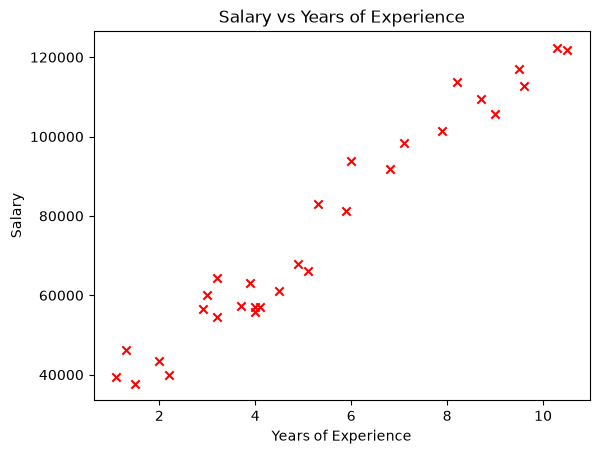

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/Salary_Data.csv')
x = df['YearsExperience'].values
y = df['Salary'].values

plt.scatter(x, y, marker='x', c='r')
plt.title('Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

## 2. The Model Function

The linear regression model representation for a single feature is defined by the linear equation:

$$f_{w,b}(x^{(i)}) = wx^{(i)} + b$$

Where:
* $x^{(i)}$ is the input feature for the $i$-th training example (Years of Experience).
* $w$ is the **weight** parameter (slope of the line).
* $b$ is the **bias** parameter (y-intercept).
* $f_{w,b}(x^{(i)})$ is the estimated target value predicted by our model.

The function below loops through all $m$ training examples to calculate the predicted values ($f_{wb}$) for a given set of parameters $w$ and $b$.

In [4]:
def compute_model_output(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb

## 3. The Cost Function ($J(w,b)$)

To measure how well our regression line fits the dataset, we implement the **Squared Error Cost Function** (also known as Mean Squared Error). 

The mathematical formulation is:
$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Where:
* $(f_{w,b}(x^{(i)}) - y^{(i)})$ is the **error** (the difference between the model's prediction and the actual salary value).
* Squaring the error ensures that positive and negative errors don't cancel each other out, and heavily penalizes larger deviations.
* The $\frac{1}{2m}$ term scales the sum over all training examples to find the average cost, with the extra factor of 2 simplifying future derivative calculations.

In [5]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum += cost
    total_cost = (1 / (2 * m)) * cost_sum
    return total_cost

## 4. Optimization Using Gradient Descent

To minimize our cost function $J(w,b)$ and find the optimal parameters, we implement the **Gradient Descent** algorithm. 

### Gradient Computation
At each step, we calculate the partial derivatives of the cost function with respect to our parameters $w$ and $b$:

$$\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)}$$
$$\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})$$

### Parameter Updates
We then update $w$ and $b$ simultaneously in the opposite direction of the gradient, scaled by a learning rate ($\alpha$):

$$w = w - \alpha \frac{\partial J(w,b)}{\partial w}$$
$$b = b - \alpha \frac{\partial J(w,b)}{\partial b}$$

This loop repeats for a set number of iterations (`num_iters`) until the parameters converge on the minimum cost.

In [1]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw += (f_wb - y[i]) * x[i]
        dj_db += (f_wb - y[i])
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

def gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    w = w_in
    b = b_in
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J_history.append(compute_cost(x, y, w, b))
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {J_history[-1]:.2f}, w={w:.4f}, b={b:.4f}")
    return w, b, J_history

## 5. Training the Model

With our optimization functions constructed, we configure our execution parameters to train the model:
* **Initial Parameters ($w_{init}, b_{init}$):** We start our search at $(0,0)$, assuming zero baseline salary and zero scaling effect.
* **Learning Rate ($\alpha$):** Set to $0.01$, a safe step size ensuring stable descent without overshooting the global minimum.
* **Iterations:** We run the descent tracking for $1,000$ epochs to allow ample optimization cycles for convergence.

Let's execute the gradient descent tracking loop to uncover our final optimized parameters.

In [7]:
w_init, b_init = 0, 0
alpha = 0.01
iterations = 1000

w_final, b_final, J_hist = gradient_descent(x, y, w_init, b_init, alpha, iterations)
print(f"Final w: {w_final:.4f}, b: {b_final:.4f}")

Iteration 0: Cost 1344612525.84, w=4773.9870, b=760.0300
Iteration 100: Cost 55770801.44, w=12309.4661, b=6522.7633
Iteration 200: Cost 41914253.34, w=11763.7838, b=10199.9711
Iteration 300: Cost 32841618.72, w=11322.2347, b=13175.4533
Iteration 400: Cost 26901272.09, w=10964.9469, b=15583.1210
Iteration 500: Cost 23011804.52, w=10675.8408, b=17531.3308
Iteration 600: Cost 20465158.85, w=10441.9050, b=19107.7616
Iteration 700: Cost 18797731.63, w=10252.6115, b=20383.3603
Iteration 800: Cost 17705976.46, w=10099.4411, b=21415.5352
Iteration 900: Cost 16991145.05, w=9975.5003, b=22250.7390
Final w: 9876.1128, b: 22920.4855


## 6. Visualizing the Best Fit Line

Now that gradient descent has converged on our optimized parameters ($w_{final}$ and $b_{final}$), we can evaluate the results. 

We compute the model's final predicted values across all data points and plot our calculated **Line of Best Fit** directly over the original actual salary data distribution.

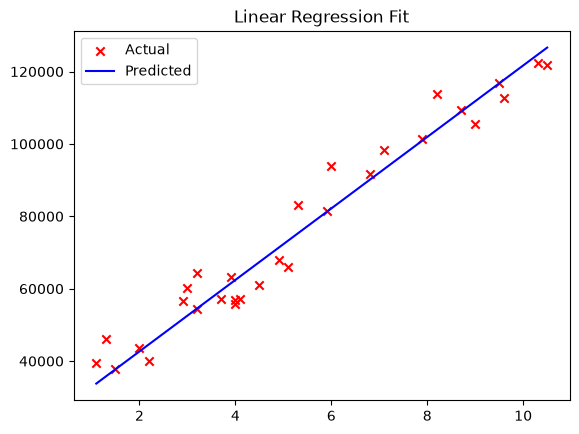

In [8]:
predicted = compute_model_output(x, w_final, b_final)
plt.scatter(x, y, marker='x', c='r', label='Actual')
plt.plot(x, predicted, c='b', label='Predicted')
plt.legend()
plt.title('Linear Regression Fit')
plt.show()

## 7. Model Inference & Prediction

The ultimate goal of training a machine learning model is to use it to predict outcomes for unseen or arbitrary inputs. 

Using our final optimized slope ($w$) and intercept ($b$), we can formulate predictions using our base hypothesis equation ($f_{w,b}(x) = wx + b$). For instance, we can plug in a specific value—such as **7 years of experience**—to estimate the expected salary trajectory based on our trained line of best fit.

In [9]:
years = 7
predicted_salary = w_final * years + b_final
print(f"Predicted salary for {years} years of experience: ${predicted_salary:,.2f}")

Predicted salary for 7 years of experience: $92,053.27
